In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

from preprocessing import rename_columns, transform_variables

| Métrica   | Importância                      |
| --------- | -------------------------------- |
| ROC-AUC   | Class division                   |
| Recall    | Find default                     |
| Precision | Prevent false positives          |
| F1-Score  | Balance                          |
| PR-AUC    | Very useful for unbalance        |


In [4]:
df = pd.read_csv('../data/credit.csv')
df = rename_columns(df).drop(df.index[0])

In [5]:
df = transform_variables(df)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         30000 non-null  str     
 1   limit_bal  30000 non-null  int64   
 2   sex        30000 non-null  category
 3   education  30000 non-null  category
 4   marriage   30000 non-null  category
 5   age        30000 non-null  int64   
 6   pay_0      30000 non-null  int64   
 7   pay_2      30000 non-null  int64   
 8   pay_3      30000 non-null  int64   
 9   pay_4      30000 non-null  int64   
 10  pay_5      30000 non-null  int64   
 11  pay_6      30000 non-null  int64   
 12  bill_amt1  30000 non-null  int64   
 13  bill_amt2  30000 non-null  int64   
 14  bill_amt3  30000 non-null  int64   
 15  bill_amt4  30000 non-null  int64   
 16  bill_amt5  30000 non-null  int64   
 17  bill_amt6  30000 non-null  int64   
 18  pay_amt1   30000 non-null  int64   
 19  pay_amt2   30000 non-null  int64   


In [6]:
df.head()

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Explicação das varíaveis:

.ID: ID of each client

.LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)

.SEX: Gender (1=male, 2=female)

.EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

.MARRIAGE: Marital status (1=married, 2=single, 3=others)

.AGE: Age in years

.PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, ... 8=payment delay for eight months, 9=payment delay for nine months and above)

.PAY_2: Repayment status in August, 2005 (scale same as above)

.PAY_3: Repayment status in July, 2005 (scale same as above)

.PAY_4: Repayment status in June, 2005 (scale same as above)

.PAY_5: Repayment status in May, 2005 (scale same as above)

.PAY_6: Repayment status in April, 2005 (scale same as above)

.BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

.BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

.BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

.BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

.BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

.BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

.PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

.PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

.PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

.PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

.PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

.PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

.default: Default payment (1=yes, 0=no)

In [7]:
df.isnull().sum()

id           0
limit_bal    0
sex          0
education    0
marriage     0
age          0
pay_0        0
pay_2        0
pay_3        0
pay_4        0
pay_5        0
pay_6        0
bill_amt1    0
bill_amt2    0
bill_amt3    0
bill_amt4    0
bill_amt5    0
bill_amt6    0
pay_amt1     0
pay_amt2     0
pay_amt3     0
pay_amt4     0
pay_amt5     0
pay_amt6     0
default      0
dtype: int64

In [8]:
df[['sex','education','marriage']].describe()

,sex,education,marriage
count,30000,30000,30000
unique,2,7,4
top,2,2,2
freq,18112,14030,15964


In [9]:
df['marriage'].value_counts()
#MARRIAGE has a label 0 that is undocumented

marriage
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [10]:
df['education'].value_counts()
#EDUCATION has category 5 and 6 that are unlabelled, moreover the category 0 is undocumented.

education
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [11]:
df['education'] = df['education'].replace([0,5,6], 4)
df['marriage'] = df['marriage'].replace(0, 3)

In [12]:
# Payment delay description
df[['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']].describe()

,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100
std,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


They all present an undocumented label -2. If 1,2,3, etc are the months of delay, 0 should be labeled 'pay duly' and every negative value should be seen as a 0.

In [13]:
# Bill Statement description
df[['bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6']].describe()

,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


Negative values can be interpreted as credit? Has to be investigated

In [14]:
#Previous Payment Description
df[['pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']].describe()

,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [15]:
df['limit_bal'].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: limit_bal, dtype: float64

In [16]:
df['default'].value_counts(normalize=True)*100

default
0    77.88
1    22.12
Name: proportion, dtype: float64

Unbalanced data that should be looked upon.

In [17]:
df.drop(columns=['id'], inplace=True)

Excluding the id row because it doesn't have any value for the prediction.

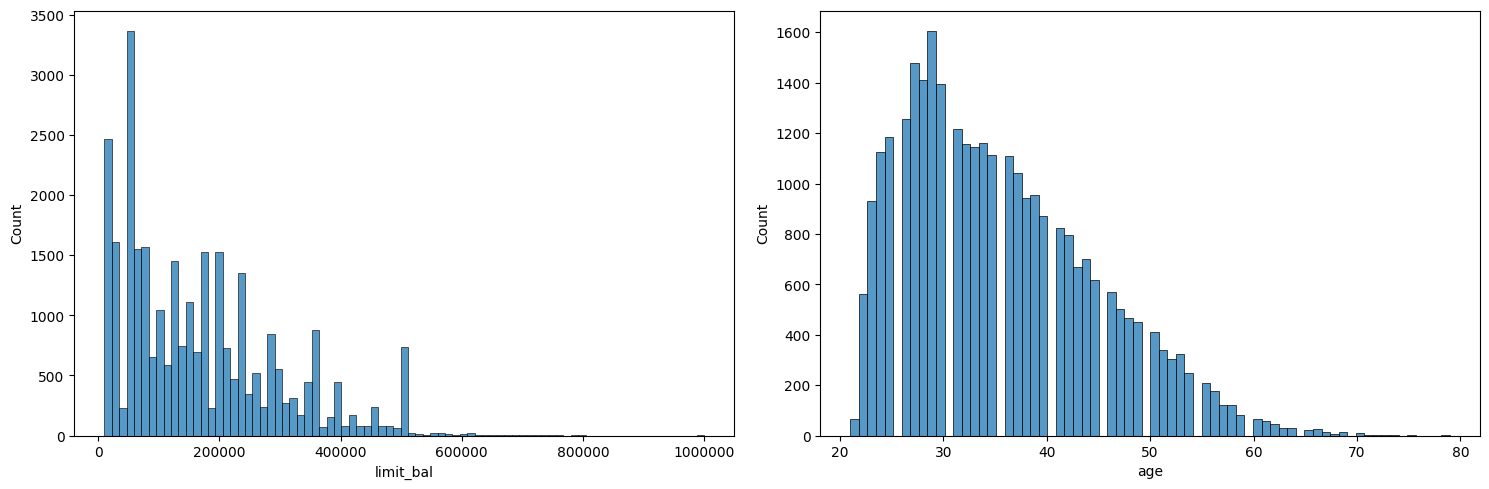

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cria a figura e os dois eixos (ax1 e ax2) de uma vez só
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Diz ao Seaborn exatamente em qual eixo desenhar cada histograma
sns.histplot(df.limit_bal, ax=ax1)
ax1.ticklabel_format(style='plain', axis='x')
sns.histplot(df.age, ax=ax2)

plt.tight_layout()
plt.show()